In [12]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [13]:
csv_path = Path('/home/admin123/Documents/SAP/Div_academy/data/housing.csv')
df = pd.read_csv(csv_path)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [15]:
df['ocean_proximity'].value_counts()    

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [16]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


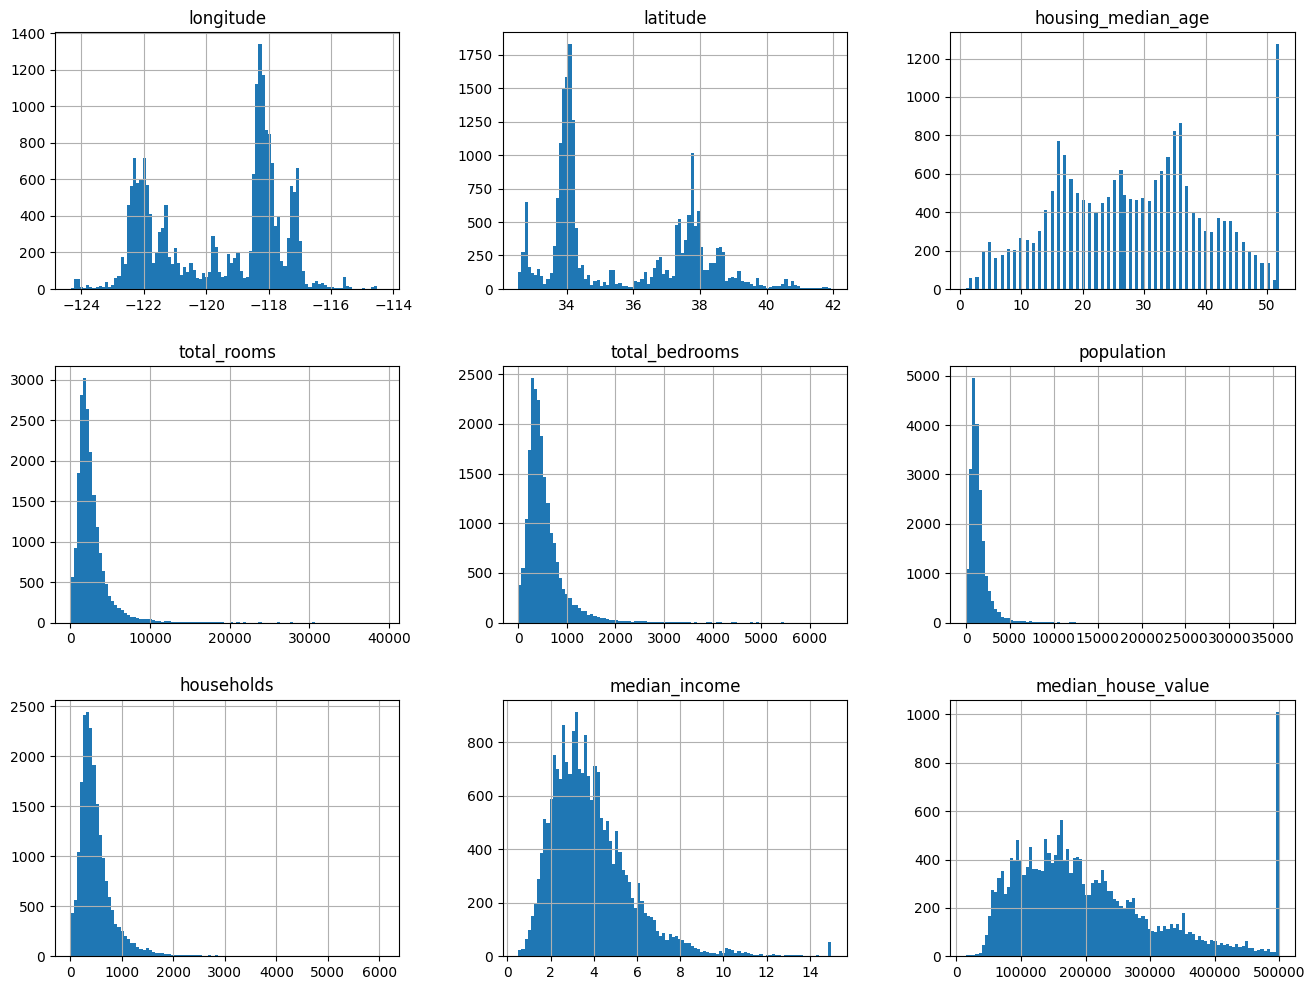

In [17]:
df.hist(bins=100, figsize=(16,12))
plt.show()

In [18]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2)
train_set.shape, test_set.shape, 

((16512, 10), (4128, 10))

In [19]:
df['income_cat'] = pd.cut(
	df['median_income'], 
    bins=[0, 1.5, 3, 4.5, 6, np.inf], 
    labels=[1,2,3,4,5],
	)

df[['income_cat', 'median_income']].head()

,income_cat,median_income
0,5,8.3252
1,5,8.3014
2,5,7.2574
3,4,5.6431
4,3,3.8462


<Axes: xlabel='income_cat'>

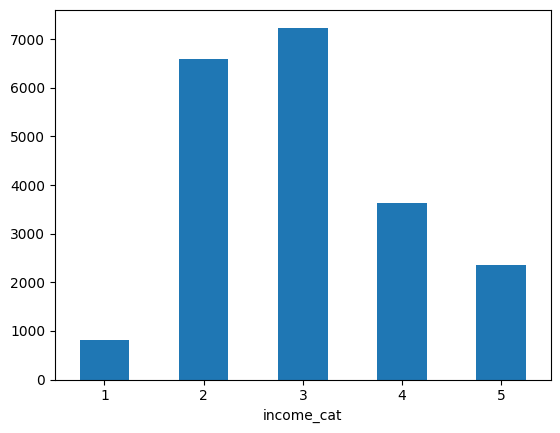

In [20]:
ic = df['income_cat'].value_counts().sort_index()
ic.plot.bar(rot=0)

In [21]:
from sklearn.model_selection import train_test_split


train_set, test_set = train_test_split(
    df, 
    test_size=0.2
    )
strat_train_set, strat_test_set = train_test_split(
    df, 
    test_size=0.2, 
	stratify=df['income_cat']
    )

<Axes: xlabel='income_cat'>

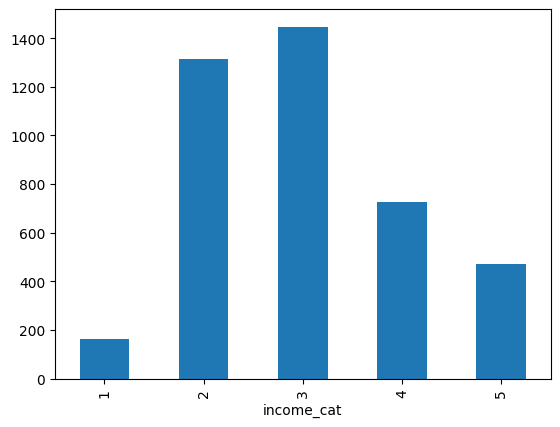

In [22]:
(
	strat_test_set['income_cat']
    .value_counts()
    .sort_index()
    .plot.bar()
)

In [23]:
# %pip install plotly nbformat

In [24]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'income_cat'],
      dtype='object')

In [25]:
# import plotly.express as px

# fig = px.scatter_map(
#     df, 
# 	'latitude', 
#     'longitude', 
#     color='median_house_value',
#     color_continuous_scale='jet',
#     size='population',
#     size_max=15,
# 	zoom=4,
#     opacity=0.5,
#     )
# fig.update_layout(margin={
# 		'l':0, 
# 		'r':0, 
# 		't':0, 
# 		'b':0, 
# 	},
# 	width=800
# )

In [26]:
mhv_mean = df['median_house_value'].mean()
l_mean = df['latitude'].mean()

nominator = (
(df['median_house_value'] - mhv_mean) 
* 
(df['latitude'] - l_mean)
).sum()

X = ((df['median_house_value'] - mhv_mean)**2).sum()
Y = ((df['latitude'] - l_mean)**2).sum()
denominator = (
    np.sqrt(X * Y)
)
nominator / denominator

np.float64(-0.14416027687465927)

In [27]:
# df.select_dtypes(include='number')
corr_matrix = df.corr(numeric_only=True)
corr_matrix['median_house_value'].sort_values()

latitude             -0.144160
longitude            -0.045967
population           -0.024650
total_bedrooms        0.049686
households            0.065843
housing_median_age    0.105623
total_rooms           0.134153
median_income         0.688075
median_house_value    1.000000
Name: median_house_value, dtype: float64

In [28]:
# import plotly.express as px

# fig = px.imshow(
#     corr_matrix, 
#     color_continuous_scale='RdBu', 
#     text_auto=".2f",
# 	aspect='auto'
# )
# fig.update_layout(margin={
# 		't':0, 
# 		'b':0, 
# 	},
# 	width=400
# )  

In [29]:
# import matplotlib.pyplot as plt
# plt.scatter(
#     df['median_house_value'], 
#     df['median_income'], 
# )

In [30]:
# from pandas.plotting import scatter_matrix

# cols = [
#     'median_house_value', 'median_income', 
# 	'housing_median_age', 'total_rooms'
# ]

# scatter_matrix(
# 	df[cols], figsize=(16,16)
# )
# plt.show()

In [31]:
# px.scatter(
#     df, 
#     'median_house_value', 
#     'median_income', 
#     template='plotly_white', 
#     opacity=0.6, 
#     marginal_x='box',
#     marginal_y='box',
# )

In [32]:
df['bedroom_pct'] = (df['total_bedrooms'] / df['total_rooms'])
df.corr(numeric_only=True)['median_house_value'].sort_values()

bedroom_pct          -0.255880
latitude             -0.144160
longitude            -0.045967
population           -0.024650
total_bedrooms        0.049686
households            0.065843
housing_median_age    0.105623
total_rooms           0.134153
median_income         0.688075
median_house_value    1.000000
Name: median_house_value, dtype: float64

In [33]:
df['total_bedrooms'].mean(skipna=False)

np.float64(nan)

In [34]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat,bedroom_pct
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5,0.146591
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5,0.155797
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,5,0.129516
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4,0.184458
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3,0.172096


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           20640 non-null  float64 
 1   latitude            20640 non-null  float64 
 2   housing_median_age  20640 non-null  float64 
 3   total_rooms         20640 non-null  float64 
 4   total_bedrooms      20433 non-null  float64 
 5   population          20640 non-null  float64 
 6   households          20640 non-null  float64 
 7   median_income       20640 non-null  float64 
 8   median_house_value  20640 non-null  float64 
 9   ocean_proximity     20640 non-null  object  
 10  income_cat          20640 non-null  category
 11  bedroom_pct         20433 non-null  float64 
dtypes: category(1), float64(10), object(1)
memory usage: 1.8+ MB


In [36]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,bedroom_pct
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,0.213039
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,0.057983
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,0.100000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,0.175427
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,0.203162
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,0.239821
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000,1.000000


In [37]:
# ort = df['total_bedrooms'].median()
# df['total_bedrooms'].fillna(ort)

ort = df.select_dtypes(include='number').median()
df.fillna(ort)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat,bedroom_pct
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5,0.146591
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5,0.155797
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,5,0.129516
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4,0.184458
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3,0.172096
...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,2,0.224625
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,2,0.215208
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,2,0.215173
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,2,0.219892


In [38]:
df.dropna(axis=0)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat,bedroom_pct
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5,0.146591
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5,0.155797
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,5,0.129516
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4,0.184458
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3,0.172096
...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,2,0.224625
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,2,0.215208
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,2,0.215173
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,2,0.219892


In [39]:
df = strat_train_set.copy()
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
12016,-122.21,37.78,44.0,1729.0,414.0,1240.0,393.0,2.3125,102800.0,NEAR BAY,2
13426,-117.35,33.99,45.0,131.0,28.0,89.0,31.0,2.6071,112500.0,INLAND,2
7273,-122.24,40.51,23.0,2216.0,378.0,1006.0,338.0,4.5590,116800.0,INLAND,4
8429,-117.19,32.77,30.0,2747.0,640.0,3185.0,657.0,3.7650,238000.0,NEAR OCEAN,3
7587,-121.57,39.74,17.0,1619.0,292.0,705.0,285.0,2.4623,126100.0,INLAND,2


In [40]:
class Heyvan:
	nefes_alir = True

	def __init__(self, ad):
		self.ad = ad

h1 = Heyvan('qezenfer')
h1.ad

'qezenfer'

In [41]:
df_num = df.select_dtypes(include = 'number')
df_cat = df.select_dtypes(include = 'object')

In [42]:
null_mask = df_num.sort_index().isna().any(axis=1)
df_num.loc[null_mask].head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
16165,-121.33,38.02,31.0,1466.0,NaN,608.0,254.0,3.1827,162100.0
14938,-124.00,40.92,29.0,1429.0,NaN,672.0,266.0,2.9485,98800.0
10288,-118.50,34.46,17.0,10267.0,NaN,4956.0,1483.0,5.5061,239400.0
11218,-118.32,34.09,44.0,2666.0,NaN,2297.0,726.0,1.6760,208800.0
16075,-116.91,32.83,16.0,5203.0,NaN,2515.0,862.0,4.1050,174400.0


In [43]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy='median')
imp.fit(df_num)
# imp.statistics_
X = imp.transform(df_num)
df_num_tr = pd.DataFrame(X, columns=imp.get_feature_names_out())
# df_num_tr.loc[null_mask]

In [44]:
from sklearn.impute import KNNImputer
kimp = KNNImputer(n_neighbors=10)
kimp.fit(df_num)
X = kimp.transform(df_num)
df_num

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
12016,-122.21,37.78,44.0,1729.0,414.0,1240.0,393.0,2.3125,102800.0
13426,-117.35,33.99,45.0,131.0,28.0,89.0,31.0,2.6071,112500.0
7273,-122.24,40.51,23.0,2216.0,378.0,1006.0,338.0,4.5590,116800.0
8429,-117.19,32.77,30.0,2747.0,640.0,3185.0,657.0,3.7650,238000.0
7587,-121.57,39.74,17.0,1619.0,292.0,705.0,285.0,2.4623,126100.0
...,...,...,...,...,...,...,...,...,...
11744,-121.82,37.69,12.0,1906.0,351.0,802.0,319.0,4.9375,227700.0
10242,-118.25,34.15,32.0,1377.0,444.0,768.0,422.0,2.2621,187500.0
2316,-118.15,34.20,52.0,1786.0,306.0,1018.0,322.0,4.1518,182100.0
18250,-118.09,33.99,34.0,1369.0,270.0,1005.0,272.0,3.6920,172600.0


In [45]:
m = df['median_income'].mean()
s = df['median_income'].std()
m - 3*s, m + 3*s
outlier1 = df['median_income'] > m + 3*s
outlier2 = df['median_income'] < m - 3*s
df.loc[outlier1 | outlier2]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
20183,-117.85,33.62,13.0,5192.0,658.0,1865.0,662.0,15.0001,500001.0,<1H OCEAN,5
7777,-122.36,37.56,32.0,4684.0,540.0,1512.0,511.0,15.0001,500001.0,NEAR OCEAN,5
13411,-122.14,37.38,26.0,2859.0,343.0,951.0,336.0,10.4277,500001.0,NEAR BAY,5
11336,-119.77,34.43,28.0,3318.0,441.0,1604.0,404.0,9.7821,500001.0,NEAR OCEAN,5
1485,-122.36,37.54,23.0,6184.0,747.0,2165.0,700.0,10.1675,500001.0,NEAR OCEAN,5
...,...,...,...,...,...,...,...,...,...,...,...
13136,-118.37,33.77,26.0,6339.0,876.0,2540.0,880.0,10.1447,500001.0,NEAR OCEAN,5
478,-117.58,33.60,5.0,5348.0,659.0,1862.0,555.0,11.0567,495400.0,<1H OCEAN,5
3879,-122.12,37.94,22.0,4949.0,626.0,1850.0,590.0,10.4549,500001.0,NEAR BAY,5
15151,-118.86,34.16,16.0,1509.0,216.0,578.0,235.0,10.2614,410800.0,<1H OCEAN,5


In [46]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(df_num)
X = ss.transform(df_num)
df_num_ss = pd.DataFrame(X, columns=ss.get_feature_names_out())
o1 = (df_num_ss < -3 ).any(axis=1)
o2 = (df_num_ss > 3 ).any(axis=1)
df_num_ss.loc[o1 | o2]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
72,-1.148668,0.816916,-1.085179,2.515309,3.722430,6.401141,4.094307,-0.284443,0.028533
74,0.704572,-0.483023,-2.117368,3.811425,2.372540,2.320652,2.238165,1.376680,-0.022430
111,0.859843,-0.942929,-1.243977,1.162721,0.280798,0.379921,0.418166,5.857852,2.530954
128,-1.399106,0.906082,0.264606,0.931370,0.003777,0.073124,0.028351,5.857852,2.530954
162,-1.288914,0.821609,-0.211789,0.100234,-0.458707,-0.414449,-0.423422,3.451149,2.530954
...,...,...,...,...,...,...,...,...,...
16392,0.353959,-0.689511,-1.005780,-0.514578,-0.756857,-0.738629,-0.684160,3.363616,1.760441
16410,0.684537,-0.675432,0.741001,-0.210816,-0.639475,-0.547424,-0.663507,5.857852,2.530954
16442,-1.208773,0.746523,1.376194,3.392441,3.220036,1.999080,3.306931,0.716421,2.530954
16447,-0.983379,1.337831,-1.879170,11.490661,10.537612,9.131896,11.242644,0.531670,0.044946


In [50]:
m = df_num.median()
q1 = df_num.quantile(q = 0.25)
q3 = df_num.quantile(q = 0.75)
iqr = np.abs(q3-q1)

lower_fence = q1 - 1.5*iqr
upper_fence = q3 + 1.5*iqr

outlier_mask = (df_num < lower_fence) | (df_num > upper_fence)
outlier_mask = outlier_mask.any(axis=1)
df_num.loc[outlier_mask]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
8429,-117.19,32.77,30.0,2747.0,640.0,3185.0,657.0,3.7650,238000.0
19808,-122.45,37.79,46.0,2009.0,464.0,761.0,453.0,3.7188,500001.0
10249,-122.45,37.78,52.0,1345.0,291.0,560.0,294.0,3.7159,494400.0
5004,-117.12,32.95,4.0,9018.0,1572.0,4438.0,1498.0,4.9880,263700.0
5362,-117.92,33.67,14.0,6224.0,1679.0,3148.0,1589.0,4.2071,430900.0
...,...,...,...,...,...,...,...,...,...
16207,-120.63,35.59,9.0,5782.0,1184.0,3026.0,1130.0,2.6528,113500.0
4444,-117.30,33.22,4.0,14960.0,2988.0,6666.0,2612.0,3.7568,184100.0
4156,-118.29,34.06,27.0,2456.0,1111.0,4137.0,1104.0,1.5954,187500.0
9428,-117.87,33.60,20.0,3212.0,572.0,1064.0,526.0,6.6155,500001.0
